## Regularization
Regularization is basically reducing weights and bias so that model does not overfit

We change the loss function with: 
$$
E(w,b) = L(w,b) + \alpha R(w)
$$

- L is original loss function 
- R is regularization term (penalty)


1. ___Ridge (L2 regularization)___:
$$
E(w,b) = L(w,b) + \alpha ||w||^2
$$

- _Pros_:
    - Ridge is Effective if all the features are important and should be kept in the model
- _Cons_:
    - Since it doesnt eleminate any feature, it doesnt help in feature selection either


2. ___Lasso (L1 regularization)___:  
Stands for _Least Absolute Shrinkage and Selection Operator_  
$$
E(w,b) = L(w,b) + \alpha ||w||
$$

- _Pros_:
    - Lasso helps in feature selection, hence it is suitable when we have many features and some may be irrelevant 
- _Cons_:
    - It only keeps highly correlated features and hence may remove some features that shouldve be retained

3. ___Elastic Net (L1+L2)___:
$$
E(w,b) = L(w,b) + \alpha ||w|| + \frac{1-\alpha}{2} ||w^2||
$$

- _Pros_: 
    - It’s especially useful when the number of predictors is much greater than the number of observations, or when there are correlations among the predictors.

- _Cons_: 
    - May require hyperparameter tuning to select best value of alpha

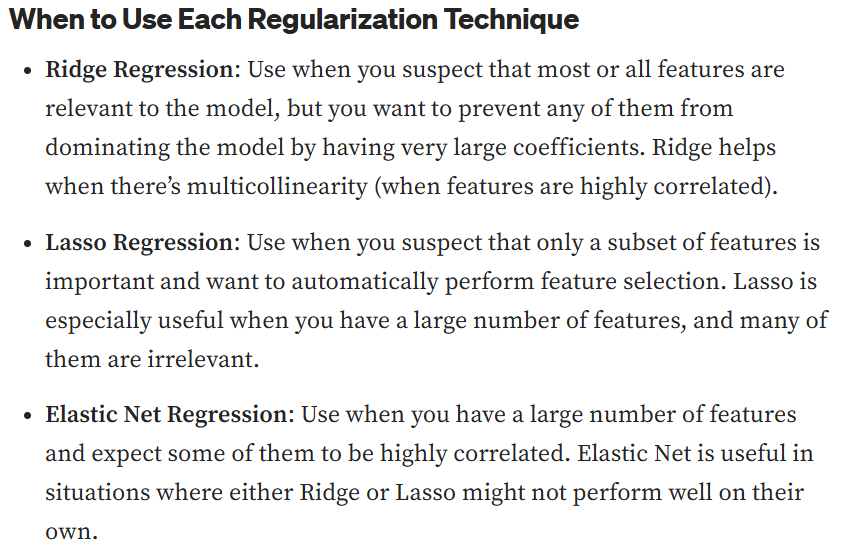

### How regularization shrink the weights?  
Consider the image, above is original function used in gradient descent for updating weights. And below derived is new function after adding penalties in loss function 

Clearly the new function for weights updation reduces the weights compared to before

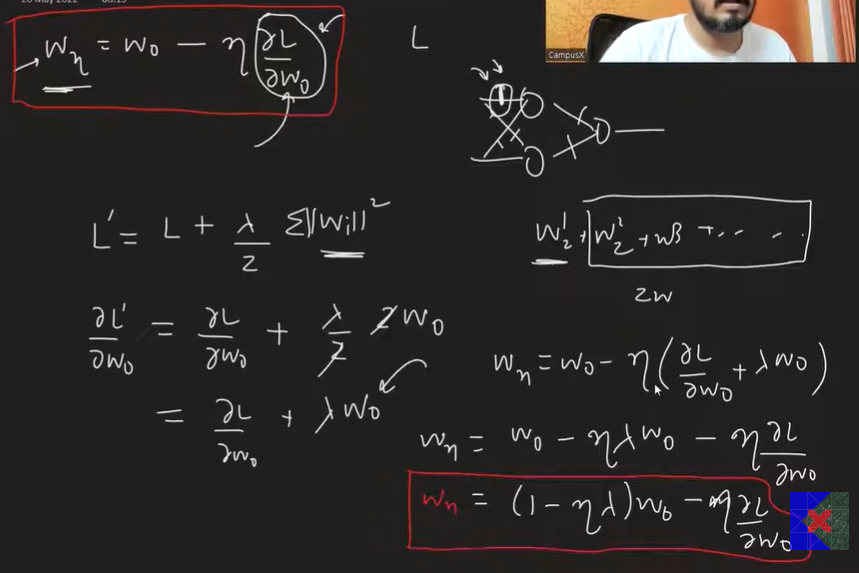

### Code demonstration

___Without regularization___

In [53]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

from sklearn.datasets import make_moons

from keras import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam
from keras.regularizers import l1, l2, l1_l2

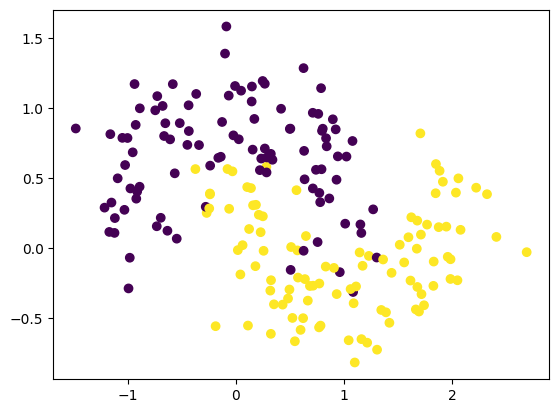

In [55]:
X, y= make_moons(n_samples=200, noise=0.25, random_state=10)
plt.scatter(X[:,0],X[:,1],c=y)

In [56]:
model1 = Sequential()

model1.add(Input(shape=(X.shape[1],)))
model1.add(Dense(128, activation='relu'))
model1.add(Dense(128, activation='relu'))
model1.add(Dense(128, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

adam = Adam(learning_rate=0.01)
model1.compile(optimizer = adam, loss='binary_crossentropy', metrics=['Accuracy'])
history1 = model1.fit(X,y, epochs=300, verbose=1, validation_split=0.2 )

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - Accuracy: 0.8125 - loss: 0.5073 - val_Accuracy: 0.7250 - val_loss: 0.5060
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - Accuracy: 0.8625 - loss: 0.4258 - val_Accuracy: 0.7500 - val_loss: 0.5823
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - Accuracy: 0.8813 - loss: 0.3025 - val_Accuracy: 0.7750 - val_loss: 0.4063
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - Accuracy: 0.8750 - loss: 0.3012 - val_Accuracy: 0.7500 - val_loss: 0.4101
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - Accuracy: 0.8813 - loss: 0.2679 - val_Accuracy: 0.7750 - val_loss: 0.4267
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - Accuracy: 0.8875 - loss: 0.2506 - val_Accuracy: 0.8250 - val_loss: 0.3936
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - Accuracy: 0.9062 - loss: 0.2378 - val_Accuracy: 0.8250 - val_loss: 0.3555
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - Accuracy: 0.9187 - loss: 0.2050 - val_Accuracy: 0.8000 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 773us/step


<Axes: >

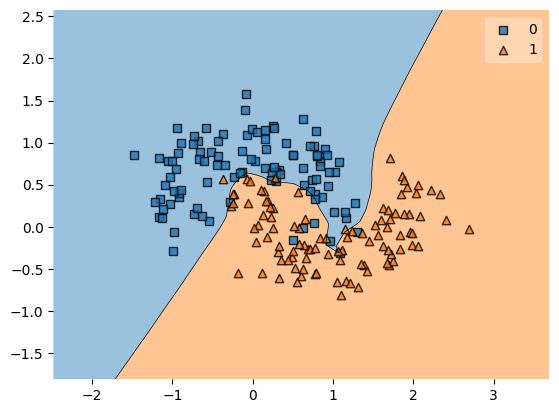

In [57]:
plot_decision_regions(X,y, clf=model1)

___With Ridge___

In [58]:
model2 = Sequential()

model2.add(Input(shape=(X.shape[1],)))
model2.add(Dense(128, activation='relu', kernel_regularizer=l2))  #default value of l2=0.01
model2.add(Dense(128, activation='relu', kernel_regularizer=l2))
model2.add(Dense(128, activation='relu', kernel_regularizer=l2))
model2.add(Dense(1, activation='sigmoid'))

adam = Adam(learning_rate=0.01)
model2.compile(optimizer = adam, loss='binary_crossentropy', metrics=['Accuracy'])
history2 = model2.fit(X,y, epochs=300, verbose=1, validation_split=0.2)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - Accuracy: 0.7812 - loss: 2.4013 - val_Accuracy: 0.7750 - val_loss: 1.4830
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - Accuracy: 0.8625 - loss: 1.0571 - val_Accuracy: 0.7500 - val_loss: 0.8129
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - Accuracy: 0.8750 - loss: 0.5892 - val_Accuracy: 0.7750 - val_loss: 0.6216
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - Accuracy: 0.8813 - loss: 0.4997 - val_Accuracy: 0.7500 - val_loss: 0.6916
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - Accuracy: 0.8625 - loss: 0.5079 - val_Accuracy: 0.7500 - val_loss: 0.6496
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - Accuracy: 0.8813 - loss: 0.4654 - val_Accuracy: 0.7500 - val_loss: 0.5943
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - Accuracy: 0.8813 - loss: 0.4249 - val_Accuracy: 0.7750 - val_loss: 0.5601
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - Accuracy: 0.8750 - loss: 0.4623 - val_Accuracy: 0.7500 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 691us/step


<Axes: >

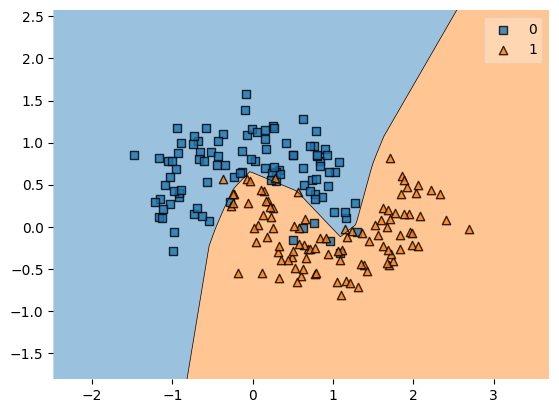

In [59]:
plot_decision_regions(X,y, clf=model2)

___With Lasso___

In [60]:
model3 = Sequential()

model3.add(Input(shape=(X.shape[1],)))
model3.add(Dense(128, activation='relu', kernel_regularizer=l1(0.001))) 
model3.add(Dense(128, activation='relu', kernel_regularizer=l1(0.001)))
model3.add(Dense(128, activation='relu', kernel_regularizer=l1(0.001)))
model3.add(Dense(1, activation='sigmoid'))

adam = Adam(learning_rate=0.01)
model3.compile(optimizer = adam, loss='binary_crossentropy', metrics=['Accuracy'])
history3 = model3.fit(X,y, epochs=300, verbose=1, validation_split=0.2)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - Accuracy: 0.6187 - loss: 2.6705 - val_Accuracy: 0.7750 - val_loss: 1.9544
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - Accuracy: 0.8687 - loss: 1.5308 - val_Accuracy: 0.7250 - val_loss: 1.4803
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - Accuracy: 0.8562 - loss: 1.0729 - val_Accuracy: 0.7750 - val_loss: 1.0341
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - Accuracy: 0.8687 - loss: 0.8662 - val_Accuracy: 0.7500 - val_loss: 0.9461
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - Accuracy: 0.8875 - loss: 0.7626 - val_Accuracy: 0.7500 - val_loss: 0.7924
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - Accuracy: 0.8750 - loss: 0.6320 - val_Accuracy: 0.7500 - val_loss: 0.7928
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - Accuracy: 0.8813 - loss: 0.5696 - val_Accuracy: 0.7750 - val_loss: 0.7066
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - Accuracy: 0.8750 - loss: 0.5236 - val_Accuracy: 0.7750 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step


<Axes: >

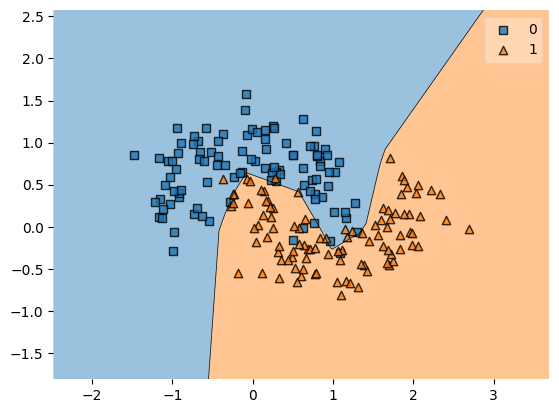

In [61]:
plot_decision_regions(X,y, clf=model3)

___Elastic net___

In [62]:
model4 = Sequential()

model4.add(Input(shape=(X.shape[1],)))
model4.add(Dense(128, activation='relu', kernel_regularizer=l1_l2(0.005))) 
model4.add(Dense(128, activation='relu', kernel_regularizer=l1_l2(0.005)))
model4.add(Dense(128, activation='relu', kernel_regularizer=l1_l2(0.005)))
model4.add(Dense(1, activation='sigmoid'))

adam = Adam(learning_rate=0.01)
model4.compile(optimizer = adam, loss='binary_crossentropy', metrics=['Accuracy'])
history4 = model4.fit(X,y, epochs=300, verbose=1, validation_split=0.2)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - Accuracy: 0.8313 - loss: 10.4688 - val_Accuracy: 0.7250 - val_loss: 6.8202
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - Accuracy: 0.8188 - loss: 5.1212 - val_Accuracy: 0.7500 - val_loss: 3.2284
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - Accuracy: 0.8375 - loss: 2.5894 - val_Accuracy: 0.7500 - val_loss: 2.3498
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - Accuracy: 0.8562 - loss: 2.3127 - val_Accuracy: 0.7250 - val_loss: 2.2486
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - Accuracy: 0.8750 - loss: 1.8459 - val_Accuracy: 0.7250 - val_loss: 1.5482
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - Accuracy: 0.8687 - loss: 1.3288 - val_Accuracy: 0.7750 - val_loss: 1.3820
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - Accuracy: 0.8375 - loss: 1.2129 - val_Accuracy: 0.8000 - val_loss: 1.3030
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - Accuracy: 0.8625 - loss: 1.0313 - val_Accuracy: 0.7750 - val_los

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 789us/step


<Axes: >

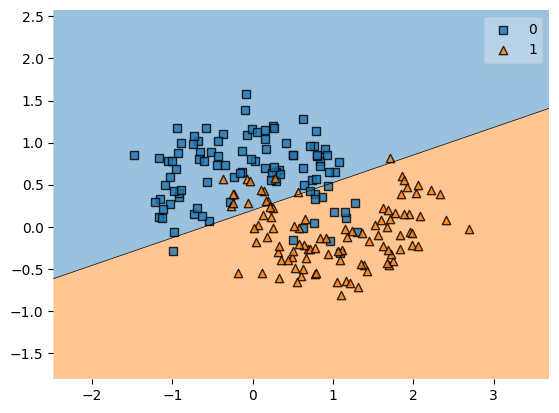

In [63]:
plot_decision_regions(X,y, clf=model4)

### Plots

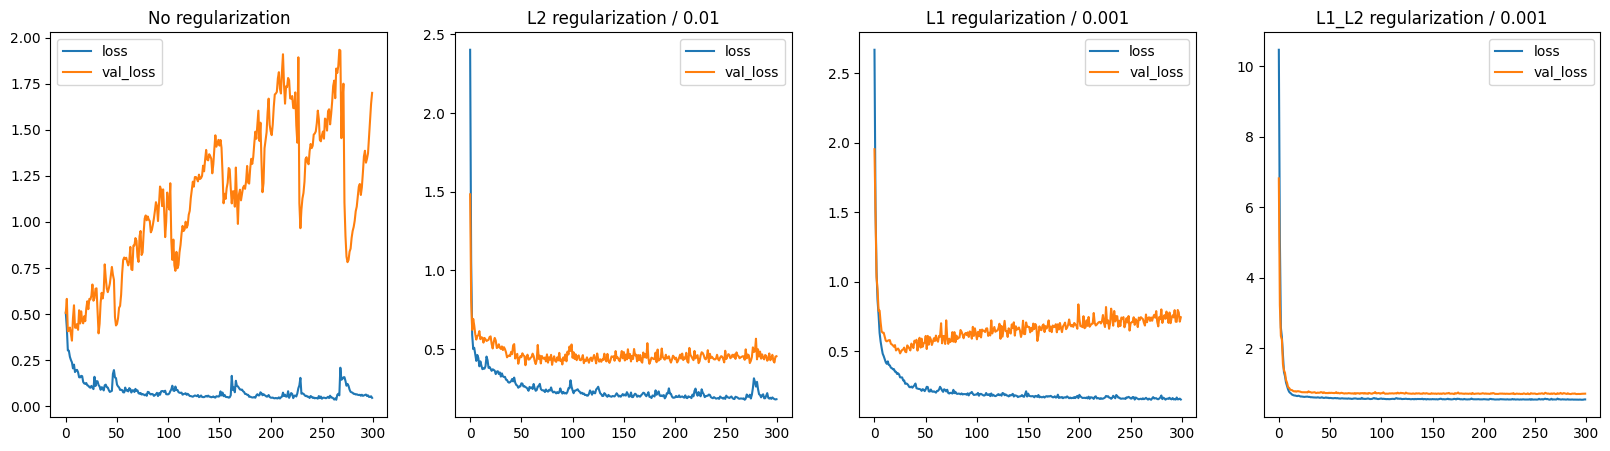

In [66]:
plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
plt.title("No regularization")
plt.plot(history1.history['loss'], label='loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.legend()

plt.subplot(1,4,2)
plt.title("L2 regularization / 0.01")
plt.plot(history2.history['loss'], label='loss')
plt.plot(history2.history['val_loss'], label='val_loss')
plt.legend()


plt.subplot(1,4,3)
plt.title("L1 regularization / 0.001")
plt.plot(history3.history['loss'], label='loss')
plt.plot(history3.history['val_loss'], label='val_loss')
plt.legend()

plt.subplot(1,4,4)
plt.title("L1_L2 regularization / 0.001")
plt.plot(history4.history['loss'], label='loss')
plt.plot(history4.history['val_loss'], label='val_loss')
plt.legend()

In [73]:
model1.get_weights()[0].reshape(256)

array([ 2.07230374e-01,  4.00799274e-01, -8.65594074e-02, -1.72406286e-02,
        2.09419683e-01, -2.28018850e-01, -1.51748106e-01, -8.54974538e-02,
       -1.28010968e-02, -9.47912186e-02,  1.67699188e-01, -2.21739084e-01,
       -1.59575865e-01, -6.56602740e-01,  3.13705951e-01, -6.51963890e-01,
        6.73999917e-03, -7.22979307e-01, -2.90039361e-01,  5.45307100e-01,
       -6.49035215e-01, -6.44429848e-02,  8.66738334e-02, -3.46885443e-01,
        3.56299788e-01,  3.43581825e-03, -1.14406906e-01, -7.17479885e-02,
        4.47988778e-01,  4.53977197e-01,  8.51547047e-02, -2.59945244e-01,
       -2.68625617e-01, -1.88406199e-01, -5.62109463e-02, -1.72211081e-01,
       -8.25092420e-02, -3.20392191e-01, -6.00538440e-02, -2.33049288e-01,
       -1.21742390e-01, -6.12894177e-01, -6.07060432e-01,  3.91255558e-01,
        2.60708071e-02, -1.83749020e-01, -2.50616908e-01,  4.53202844e-01,
       -5.94563663e-01, -2.93559581e-02, -6.24502182e-01,  3.26156974e-01,
        5.33874571e-01, -

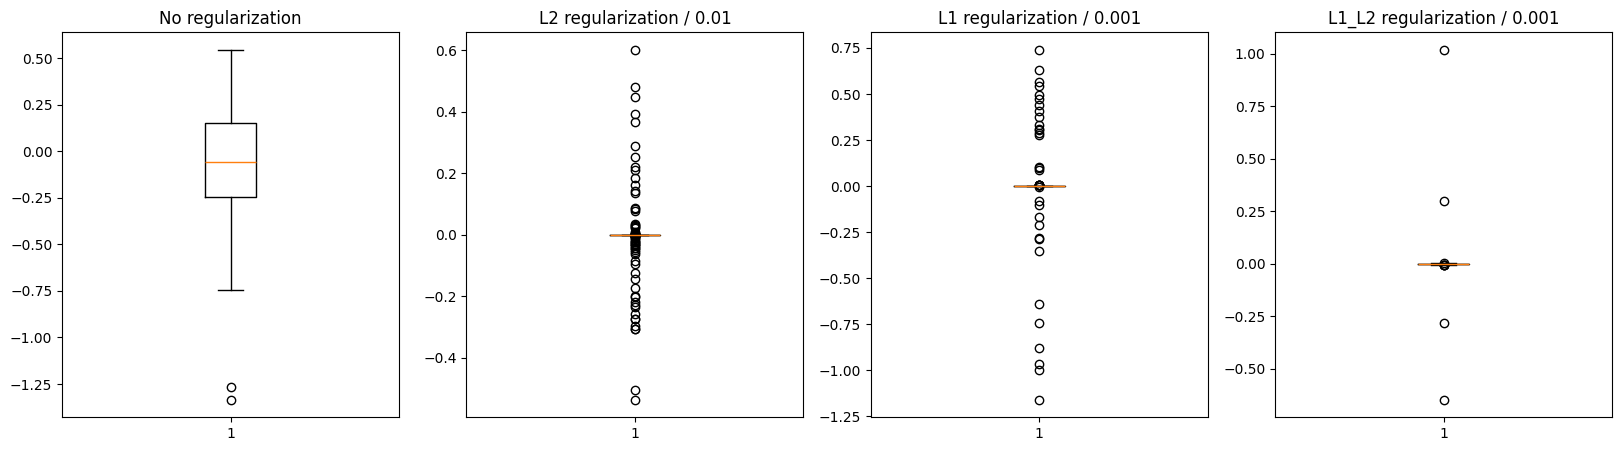

In [77]:
#Box plots for weights
plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
plt.title("No regularization")
plt.boxplot(model1.get_weights()[0].reshape(256))

plt.subplot(1,4,2)
plt.title("L2 regularization / 0.01")
plt.boxplot(model2.get_weights()[0].reshape(256))


plt.subplot(1,4,3)
plt.title("L1 regularization / 0.001")
plt.boxplot(model3.get_weights()[0].reshape(256))

plt.subplot(1,4,4)
plt.title("L1_L2 regularization / 0.001")
plt.boxplot(model4.get_weights()[0].reshape(256))

plt.show()

In 'no regularization' weights are distributed from -1.25 to 0.5, but when regularization is used, boxx plots shrank close to zero

This is what we call `Weights Decay`